# **Experiment Notebook 2**



In [1]:
# Do not modify this code
%pip install -q utstd

from utstd.ipyrenders import *

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [3]:
import os, json, math, pathlib, warnings
from datetime import date
from collections import Counter
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Any
from joblib import dump

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.calibration import CalibratedClassifierCV


from amla_at1.data.openmeteo import fetch_daily_archive, make_supervised_tables
from amla_at1.data.time_split import split_by_date
from amla_at1.features.weather import clip_and_fill, normalize_cols
from amla_at1.models.export import save_model

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
np.set_printoptions(suppress=True, floatmode="fixed", linewidth=140)
pd.set_option("display.width", 180)

# Project paths

ROOT = Path.cwd().resolve()
DATA_DIR = (ROOT / "../precipitation_fall/data").resolve()
RAW_DIR = DATA_DIR / "raw"
PROC_DIR = DATA_DIR / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

@dataclass
class _Artifacts:
    folder_path: Path = PROC_DIR
at = _Artifacts()

---
## A. Project Description


In [4]:
# <Student to fill this section>
student_name = "Nayna Jahan Neha"
student_id = "25238736"

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## B. Business Understanding

In [7]:
# <Student to fill this section>
business_use_case_description = """
The goal is to provide an API that predicts the total precipitation (rain + snow) expected over the next 3 days in Sydney (mm), with calibrated estimates and error diagnostics, so operations (events, construction, logistics) can plan crews, tarping/drainage, delivery windows, and safety measures.
Hypothesis: Recent weather regime (14-day rolling signals) plus seasonality can forecast 3-day precipitation amounts better than climatology, reducing weather-related costs (delays, damage, cancellations) and improving on-time execution.
"""

In [8]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [9]:
# <Student to fill this section>
business_objectives = """
The objective of the project is to get accurate results with allocation of crews/equipment, timely venue or schedule changes, reduced damage and overtime, higher on-time delivery and safety. Probabilistic/interval outputs let clients set thresholds by cost/risk.

Incorrect results can have consequences, such as, Overestimation → unnecessary prep/rescheduling, higher costs, potential alarm fatigue and Underestimation → flood/water damage, missed deadlines, safety incidents, refunds.
We therefore target lower RMSE/MAE on amounts and monitor tail errors; when confidence is low, we surface uncertainty and conservative alerts.
"""

In [10]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [11]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
The exposed results can be used via API and dashboards showing predicted 3-day precipitation (mm), confidence/intervals, and alerts. Integrated into weekly/daily planning, scheduling, and automated playbooks (tarping, drainage, rerouting). Users include operations planners, site/venue managers, dispatch/logistics coordinators, and product teams embedding the API. The prediction results will be impacting the data driven decisions of field crews and contractors (rosters/safety), transport/inventory (routing, stock), finance (costs/penalties), end customers/attendees (service quality), and compliance/safety teams (risk reduction). Expectations for the project include reliable uptime, stable schema, calibrated forecasts, documented thresholds, and drift monitoring.
"""

In [12]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [13]:
CACHE = pathlib.Path("data/raw/sydney_daily_2015_2024.csv")
CACHE.parent.mkdir(parents=True, exist_ok=True)

if CACHE.exists():
    daily = pd.read_csv(CACHE, parse_dates=["date"])
    daily["date"] = daily["date"].dt.date
    daily = daily.set_index("date").sort_index()
else:
    daily = fetch_daily_archive(
        start_date="2015-01-01",
        end_date="2024-12-31",
        timezone="Australia/Sydney"
    )
    daily.to_csv(CACHE, index=True)

daily.head(5)

,weather_code,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,sunshine_duration,daylight_duration,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration
date,,,,,,,,,,,,,,,,
2015-01-01,3,27.0,20.2,31.8,22.2,0.0,0.0,0.0,0.0,48474.35,51701.08,17.3,37.4,59,29.62,5.48
2015-01-02,3,26.7,21.0,30.6,22.5,0.0,0.0,0.0,0.0,24758.28,51668.00,16.0,34.6,140,20.24,3.91
2015-01-03,3,27.4,21.5,32.4,25.4,0.0,0.0,0.0,0.0,44821.78,51631.56,21.1,45.4,52,28.44,5.30
2015-01-04,63,29.2,21.0,35.4,22.2,10.2,10.2,0.0,5.0,41183.68,51591.87,21.9,46.8,95,26.66,5.37
2015-01-05,51,23.6,20.6,25.6,21.3,0.5,0.5,0.0,4.0,8040.91,51549.03,16.8,32.0,150,10.44,2.37


### C.2 Define Target variable

In [14]:
# For precipitation_fall: regression target = sum of precipitation next 3 days (D+1..D+3)

X_cls, y_cls, X_reg, y_reg = make_supervised_tables(
    daily_df=daily,
    rain_label_lag_days=7,    
    precip_window_days=3,
    feature_lookback_days=14,
)

df_reg = pd.concat([X_reg, y_reg.rename("precip_next3_sum")], axis=1).dropna()
df_reg.head(3)

,temperature_2m_max_mean_14,temperature_2m_max_std_14,temperature_2m_max_sum_14,temperature_2m_min_mean_14,temperature_2m_min_std_14,temperature_2m_min_sum_14,apparent_temperature_max_mean_14,apparent_temperature_max_std_14,apparent_temperature_max_sum_14,apparent_temperature_min_mean_14,apparent_temperature_min_std_14,apparent_temperature_min_sum_14,precipitation_sum_mean_14,precipitation_sum_std_14,precipitation_sum_sum_14,rain_sum_mean_14,rain_sum_std_14,rain_sum_sum_14,wind_speed_10m_max_mean_14,wind_speed_10m_max_std_14,wind_speed_10m_max_sum_14,wind_gusts_10m_max_mean_14,wind_gusts_10m_max_std_14,wind_gusts_10m_max_sum_14,shortwave_radiation_sum_mean_14,shortwave_radiation_sum_std_14,shortwave_radiation_sum_sum_14,et0_fao_evapotranspiration_mean_14,et0_fao_evapotranspiration_std_14,et0_fao_evapotranspiration_sum_14,sunshine_duration_mean_14,sunshine_duration_std_14,sunshine_duration_sum_14,month,dayofyear,is_summer,precip_next3_sum
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-03,27.033333,0.351188,81.1,20.900,0.655744,62.7,31.60,0.916515,94.8,23.366667,1.767295,70.1,0.00,0.000000,0.0,0.00,0.000000,0.0,18.133333,2.650157,54.4,39.133333,5.604760,117.4,26.10,5.109090,78.30,4.896667,0.859205,14.69,39351.4700,12769.346604,118054.41,1,3,1,10.2
2015-01-04,27.575000,1.120640,110.3,20.925,0.537742,83.7,32.55,2.042058,130.2,23.075000,1.556438,92.3,2.55,5.100000,10.2,2.55,5.100000,10.2,19.075000,2.868652,76.3,41.050000,5.969645,164.2,26.24,4.180941,104.96,5.015000,0.740383,20.06,39809.5225,10466.297825,159238.09,1,4,1,10.7
2015-01-05,26.780000,2.025339,133.9,20.860,0.487852,104.3,31.16,3.576031,155.8,22.720000,1.564289,113.6,2.14,4.510876,10.7,2.14,4.510876,10.7,18.620000,2.684586,93.1,39.240000,6.565668,196.2,23.08,7.939660,115.40,4.486000,1.345485,22.43,33455.8000,16852.492120,167279.00,1,5,1,12.1


In [15]:
# <Student to fill this section>
target_definition_explanations = """
`precip_next3_sum` = total precipitation (rain + snow) over D+1…D+3 (mm). Many operational decisions (crew shifts, tarping, drainage, stock, delivery windows) depend on the amount of wet weather over the next few days—not just a yes/no. A 3-day horizon balances actionability (short enough to be useful) with planning lead time. Using precipitation (not rain-only) matches business risk from any water load. Built from daily aggregates and leakage-safe features up to D, so no look-ahead.
"""

In [16]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [17]:
target_col = "precip_next3_sum"
assert target_col in df_reg.columns


### C.4 Explore Target variable

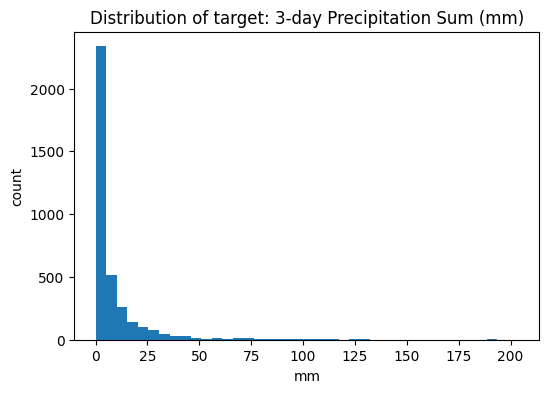

count    3650.000000
mean        8.024959
std        16.091786
min         0.000000
50%         2.200000
75%         8.500000
90%        21.800000
95%        33.310000
max       203.700000
Name: precip_next3_sum, dtype: float64

In [18]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(df_reg[target_col], bins=40)
ax.set_title("Distribution of target: 3-day Precipitation Sum (mm)")
ax.set_xlabel("mm")
ax.set_ylabel("count")
plt.show()

df_reg[target_col].describe(percentiles=[.5, .75, .9, .95])

In [19]:
# <Student to fill this section>
target_distribution_explanations = """
Target summary (precip_next3_sum, mm over D+1..D+3): highly zero-inflated and heavy right-tailed. median 2.2 mm, mean 8.0 mm, 75th=8.5, 90th=21.8, 95th=33.3, max≈204. Most cases are light or zero, with rare extreme totals; variance grows with the mean (heteroscedastic). 
RMSE will be dominated by a few storms; MAE is more robust for typical days. MAPE is unusable (zeros). Consider also quantile/Pinball loss (P50/P90) or CRPS to communicate risk. 
"""

In [20]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `precipitation_sum_mean_14`

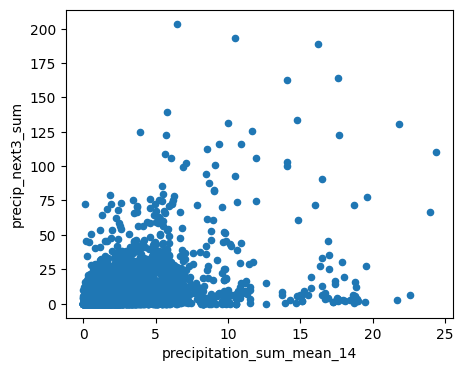

In [21]:
feat = "precipitation_sum_mean_14"
if feat in df_reg.columns:
    df_reg[[feat, target_col]].plot(kind="scatter", x=feat, y=target_col, figsize=(5,4))

In [22]:
# <Student to fill this section>
feature_1_insights = """
`precipitation_sum_mean_14` (14-day trailing mean of total precip) signals positive but weak/moderate association with next-3-day totals; captures wet/dry regime persistence. Relationship is non-linear and heteroscedastic—variance of the target grows rapidly with the feature. It's distribution is strong right skew with many near-zero values; long tail on wet periods. Consider log1p transform and robust scaling. Higher recent precip raises risk of further accumulations, but beyond ~5–10 mm/day mean the incremental signal saturates; extreme 3-day totals can still occur at mid-range feature values (other drivers matter: pressure, moisture transport, wind). Limitations include seasonality confounding (feature is higher in wet seasons); redundancy with rain_sum_mean_14; sensitive to outliers/missing days; mean level ignores volatility—std/sum over 14d often adds more signal.
"""

In [23]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `rain_sum_mean_14`

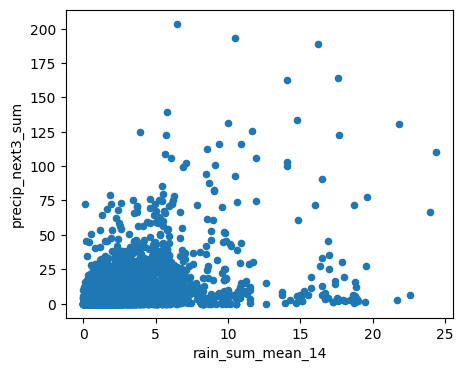

In [24]:
feat = "rain_sum_mean_14"
if feat in df_reg.columns:
    df_reg[[feat, target_col]].plot(kind="scatter", x=feat, y=target_col, figsize=(5,4))

In [25]:
# <Student to fill this section>
feature_2_insights = """
`rain_sum_mean_14` (14-day trailing mean of daily rain) signals similar to precipitation_sum_mean_14—captures recent wet regime; association with 3-day totals is positive but weak/non-linear with strong heteroscedasticity (bigger target variance at higher means). Incremental signal appears to saturate beyond ~5–8 mm/day. It's distribution is heavy right-skew with many near-zero values and a long tail during wet spells. Consider log1p and robust/winsorized handling. Limitations include near-collinear with precipitation_sum_mean_14 (redundancy—retain one or regularize); seasonality confounds level; mean ignores volatility and clustering of storms; sensitive to outliers/missing days.
"""

In [26]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest `temperature_2m_max_mean_14`


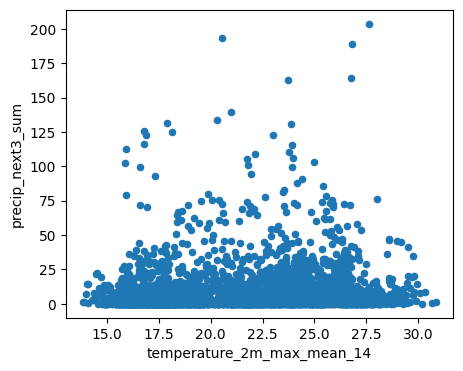

In [27]:
feat = "temperature_2m_max_mean_14"
if feat in df_reg.columns:
    df_reg[[feat, target_col]].plot(kind="scatter", x=feat, y=target_col, figsize=(5,4))

In [28]:
# <Student to fill this section>
feature_3_insights = """
`temperature_2m_max_mean_14` (14-day trailing mean of daily max temp) signals weak, non-monotonic link to 3-day precip totals. Moderate temps often coincide with higher totals (frontal systems), while very low/high temps can be dry. Relationship is noisy and heteroscedastic. It's distribution is approximately unimodal within ~15–30 °C, seasonally driven; narrower spread than precip features. Standardization helps; log transform not needed. It's limitations include strong seasonality confounding (temp ≈ season proxy); interacts with humidity/radiation/pressure rather than driving precip alone. Mean level ignores variability (heat spikes/cool changes) that precede rain.
"""

In [29]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

---
## D. Feature Selection


In [30]:
# Feature Selection Setup

all_features = [c for c in df_reg.columns if c != target_col]
print(f"Total candidate features: {len(all_features)}")

Total candidate features: 36


### D.1 Approach "Domain + rolling windows""


In [31]:
ROLL_SUFFIXES = ("_mean_14", "_std_14", "_sum_14")
CAL_FEATURES  = {"month", "dayofyear", "is_summer"}

features_d1 = [
    c for c in all_features
    if c.endswith(ROLL_SUFFIXES) or c in CAL_FEATURES
]

print(f"Selected {len(features_d1)} features (domain+rolling+calendar)")
features_d1[:12]

Selected 36 features (domain+rolling+calendar)


['temperature_2m_max_mean_14',
 'temperature_2m_max_std_14',
 'temperature_2m_max_sum_14',
 'temperature_2m_min_mean_14',
 'temperature_2m_min_std_14',
 'temperature_2m_min_sum_14',
 'apparent_temperature_max_mean_14',
 'apparent_temperature_max_std_14',
 'apparent_temperature_max_sum_14',
 'apparent_temperature_min_mean_14',
 'apparent_temperature_min_std_14',
 'apparent_temperature_min_sum_14']

In [32]:
# <Student to fill this section>
feature_selection_1_insights = """
Precip totals over the next 3 days are driven by recent weather regime and seasonality. Leakage-safe 14-day rolling stats (mean/std/sum) capture level, volatility, and accumulation without looking beyond D; calendar terms (month/dayofyear/is_summer) encode strong seasonal effects. Using the engineered signals from make_supervised_tables keeps the set interpretable, meteorologically plausible, and consistent for serving. 36 features selected covering temperature/apparent temperature, rain/precip, radiation/sunshine, wind/gusts, ET0, plus calendar. These provide broad coverage of moisture supply, lift, and energy, but include collinear pairs (e.g., mean vs sum; rain vs precip). Next: standardize where needed, use regularization/importance on time-aware CV to prune redundancy.
"""

In [33]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach "Model-based ranking (Permutation Importance)"


In [34]:
split_idx = int(len(df_reg) * 0.8)
X_imp_tr, y_imp_tr = df_reg[all_features].iloc[:split_idx],  df_reg[target_col].iloc[:split_idx]
X_imp_te, y_imp_te = df_reg[all_features].iloc[split_idx:], df_reg[target_col].iloc[split_idx:]

stub = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3, random_state=42),
    n_estimators=200, learning_rate=0.1, random_state=42
)
stub.fit(X_imp_tr, y_imp_tr)

perm = permutation_importance(stub, X_imp_te, y_imp_te, n_repeats=10, random_state=42)
perm_imp = pd.Series(perm.importances_mean, index=all_features).sort_values(ascending=False)

TOP_N = 40  # adjust as needed
features_d2 = perm_imp.head(min(TOP_N, len(perm_imp))).index.tolist()

print(f"Top-{len(features_d2)} by permutation importance")
perm_imp.head(15)

Top-36 by permutation importance


precipitation_sum_std_14           0.091781
rain_sum_std_14                    0.085539
precipitation_sum_sum_14           0.058345
rain_sum_sum_14                    0.056583
apparent_temperature_min_std_14    0.042373
precipitation_sum_mean_14          0.037182
rain_sum_mean_14                   0.032403
wind_gusts_10m_max_std_14          0.022258
wind_speed_10m_max_std_14          0.020688
sunshine_duration_std_14           0.017538
temperature_2m_min_std_14          0.014505
temperature_2m_max_std_14          0.008140
apparent_temperature_max_std_14    0.006889
wind_speed_10m_max_mean_14         0.002493
temperature_2m_max_sum_14          0.001889
dtype: float64

In [35]:
# <Student to fill this section>
feature_selection_2_insights = """
Permutation importance on a held-out, later time slice estimates each feature’s predictive contribution for a non-linear regressor, capturing interactions that univariate tests miss while respecting temporal order. It’s model-agnostic, unit-free, and highlights which inputs the stub ensemble actually uses. Volatility and accumulation dominate. The top signals are precipitation_sum_std_14 and rain_sum_std_14 (recent variability), followed by precipitation_sum_sum_14 / rain_sum_sum_14 (recent totals) and precipitation_sum_mean_14 / rain_sum_mean_14 (level). Secondary drivers include wind gust/speed stds and sunshine/temperature stds, suggesting unstable, windy, low-insolation regimes precede higher 3-day totals. Means are weaker than stds/sums; rain vs precipitation pairs are redundant. Caveats: single 80/20 split, correlated features share credit, and permutation has noise—validate stability with rolling folds before pruning.
"""

In [36]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### D.3 Approach — Correlation Filter

In [37]:
corr = df_reg[all_features + [target_col]].corr(numeric_only=True)[target_col].drop(labels=[target_col])
abs_corr = corr.abs().sort_values(ascending=False)

CORR_THRESH = 0.05  # small; tweak if you prefer
features_d3 = abs_corr[abs_corr >= CORR_THRESH].index.tolist()

# Fallback to top-K if threshold is too strict
if len(features_d3) == 0:
    K = 40
    features_d3 = abs_corr.head(min(K, len(abs_corr))).index.tolist()

print(f"Selected {len(features_d3)} features by |corr| >= {CORR_THRESH} (or fallback top-K)")
abs_corr.head(15)

Selected 26 features by |corr| >= 0.05 (or fallback top-K)


rain_sum_mean_14                    0.393212
precipitation_sum_mean_14           0.393212
rain_sum_sum_14                     0.392730
precipitation_sum_sum_14            0.392730
rain_sum_std_14                     0.377926
precipitation_sum_std_14            0.377926
sunshine_duration_std_14            0.277641
shortwave_radiation_sum_std_14      0.214363
sunshine_duration_sum_14            0.184810
sunshine_duration_mean_14           0.184616
temperature_2m_min_mean_14          0.139999
temperature_2m_min_sum_14           0.138745
apparent_temperature_min_mean_14    0.136881
apparent_temperature_min_sum_14     0.136089
dayofyear                           0.112125
Name: precip_next3_sum, dtype: float64

In [38]:
# <Student to fill this section>
feature_selection_3_insights = """
Correlation filtering is a fast, transparent sanity check to keep features with meaningful linear association to the target and drop clear noise. It’s cheap to recompute, helps stabilize simpler models, and provides an interpretable ranking before heavier methods. Strongest |corr| come from recent wetness level/accumulation/volatility (rain/precip mean≈0.39, sum≈0.39, std≈0.38). Sunshine variability is next (sunshine_duration_std_14≈0.28), then radiation variability, sunshine level, and cooler-side temperature aggregates; dayofyear also correlates. This confirms regime + seasonality dominance.
"""

In [39]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_3_insights', value=feature_selection_3_insights)

## D.4 Final Selection of Features

In [40]:
bags = [set(features_d1), set(features_d2), set(features_d3)]
counts = Counter(f for S in bags for f in S)
features_final = sorted([f for f, cnt in counts.items() if cnt >= 2])

if len(features_final) < 15:
    features_final = sorted(set(features_d1) | set(features_d2))

print(f"Final features: {len(features_final)} selected")
features_list = features_final 
features_list[:20]

Final features: 36 selected


['apparent_temperature_max_mean_14',
 'apparent_temperature_max_std_14',
 'apparent_temperature_max_sum_14',
 'apparent_temperature_min_mean_14',
 'apparent_temperature_min_std_14',
 'apparent_temperature_min_sum_14',
 'dayofyear',
 'et0_fao_evapotranspiration_mean_14',
 'et0_fao_evapotranspiration_std_14',
 'et0_fao_evapotranspiration_sum_14',
 'is_summer',
 'month',
 'precipitation_sum_mean_14',
 'precipitation_sum_std_14',
 'precipitation_sum_sum_14',
 'rain_sum_mean_14',
 'rain_sum_std_14',
 'rain_sum_sum_14',
 'shortwave_radiation_sum_mean_14',
 'shortwave_radiation_sum_std_14']

In [41]:
# <Student to fill this section>
feature_selection_explanations = """
Final feature set: Majority vote across Domain+Rolling+Calendar (D.1), Permutation Importance (D.2), and Correlation Filter (D.3) kept 36 features that are both meteorologically plausible and empirically useful. The set emphasizes recent wetness level/accumulation/volatility (rain/precip means/sums/stds), energy/insolation (shortwave, sunshine), temperature/apparent temperature aggregates, ET₀, wind/gust variability, and calendar seasonality (month/dayofyear/is_summer). This balances interpretability and predictive power while remaining leakage-safe. Caveat: several pairs are collinear (rain vs precip; mean vs sum). Next: standardize where needed, use time-aware CV with regularization/SHAP to prune redundancies and lock a minimal, stable subset for the regression model.
"""

In [42]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation - Cleaning (replace inf, interpolate small gaps)

In [43]:
clean = clip_and_fill(df_reg)

In [44]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Cleaning (replace inf, interpolate small gaps) prevents broken rolls/scalers and model crashes, tames sensor/glitch spikes, and preserves sample size without deleting rows. Time-causal interpolation (no look-ahead) stabilizes distributions, reduces variance, and keeps train→serve behavior consistent. Small bias trade-off, big gains in robustness and reproducibility.
"""

In [45]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation - Normalization of a few heavy-tailed drivers

In [46]:
norm_cols = [c for c in features_list if c.endswith(("_mean_14","_sum_14","_std_14"))]
clean_norm = normalize_cols(clean, norm_cols)

In [47]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Normalization of heavy-tailed drivers stabilizes scale and tails (means/sums/stds vary orders of magnitude), improving optimizer behavior, regularization, and calibration for linear/GBDT models. Reduces dominance of large-magnitude features, mitigates heteroscedastic loss spikes, and yields more stable, comparable coefficients while preserving leakage safety (fit transform on Train only).
"""

In [48]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation - Final modeling table

In [49]:
model_df = clean_norm[features_list + [target_col]].dropna().copy()
model_df.head(3)

,apparent_temperature_max_mean_14,apparent_temperature_max_std_14,apparent_temperature_max_sum_14,apparent_temperature_min_mean_14,apparent_temperature_min_std_14,apparent_temperature_min_sum_14,dayofyear,et0_fao_evapotranspiration_mean_14,et0_fao_evapotranspiration_std_14,et0_fao_evapotranspiration_sum_14,is_summer,month,precipitation_sum_mean_14,precipitation_sum_std_14,precipitation_sum_sum_14,rain_sum_mean_14,rain_sum_std_14,rain_sum_sum_14,shortwave_radiation_sum_mean_14,shortwave_radiation_sum_std_14,shortwave_radiation_sum_sum_14,sunshine_duration_mean_14,sunshine_duration_std_14,sunshine_duration_sum_14,temperature_2m_max_mean_14,temperature_2m_max_std_14,temperature_2m_max_sum_14,temperature_2m_min_mean_14,temperature_2m_min_std_14,temperature_2m_min_sum_14,wind_gusts_10m_max_mean_14,wind_gusts_10m_max_std_14,wind_gusts_10m_max_sum_14,wind_speed_10m_max_mean_14,wind_speed_10m_max_std_14,wind_speed_10m_max_sum_14,precip_next3_sum
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-03,1.845819,-2.309256,-2.739183,1.862374,-1.029668,-1.303966,3,1.318534,-0.117026,-1.966969,1,1,-0.895003,-0.938215,-0.894040,-0.895003,-0.938215,-0.894040,1.645813,0.472615,-2.025150,0.980278,0.817078,-4.583064,1.432884,-2.191953,-4.297930,1.709831,-2.217098,-2.123172,-0.434517,-1.626409,-5.156939,-0.670451,-1.932902,-4.856396,10.2
2015-01-04,2.021414,-1.380390,-2.271264,1.812064,-1.323453,-1.029479,4,1.419730,-0.444359,-1.638861,1,1,-0.042346,0.074317,-0.650459,-0.042346,0.074317,-0.650459,1.670901,-0.023327,-1.683607,1.063545,0.308537,-4.053901,1.579914,-1.491684,-3.735096,1.715668,-2.430264,-1.772120,-0.134350,-1.514944,-4.641903,-0.388582,-1.795367,-4.394966,10.7
2015-01-05,1.764491,-0.114461,-1.932883,1.750830,-1.312515,-0.766119,5,0.967340,1.222587,-1.494054,1,1,-0.179440,-0.042645,-0.638519,-0.179440,-0.042645,-0.638519,1.104622,1.985087,-1.549860,-0.091458,1.718685,-3.950585,1.364120,-0.668327,-3.280204,1.700491,-2.520389,-1.427756,-0.417812,-1.332871,-4.289742,-0.524777,-1.911231,-4.040993,12.1


In [50]:
# <Student to fill this section>
data_cleaning_3_explanations = """
Final modeling table freezes the exact train/serve schema (features_final + target), after cleaning/normalizing, and drop rows still containing NaNs. This guarantees consistent column order/types, prevents silent leakage from extra fields, and avoids estimator failures on missing values. Impact: reproducible training, stable serialization to API, fewer runtime errors, and easier metric traceability.
"""

In [51]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

### F.1 Rolling stats + Seasonality

In [52]:
# Already done via make_supervised_tables in C.2: rolling stats + seasonality). No more extras have  been (e.g., interactions), to avoid leakage.

In [53]:
# <Student to fill this section>
feature_engineering_1_explanations = """
(rolling stats + seasonality): Rolling 14-day means/sums/stds capture recent moisture/energy regime and volatility; sin/cos (and calendar) encode seasonal cycles—all built only from ≤D to avoid leakage. Impact: stronger, more stable signals for precipitation amount, better generalization/calibration than raw daily inputs, and a compact, serve-ready feature set.
"""

In [54]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets (time-safe)

In [55]:
# Inclusive boundaries; pick a reasonable split across years.
X_all = model_df[features_list]
y_all = model_df[target_col]

# Boundaries: train <= 2023-12-31; val = 2024-01-01..2024-09-30; test = 2024-10-01+
dates_idx = pd.to_datetime(model_df.index)
X_all.index = dates_idx
y_all.index = dates_idx

Xtr, ytr, Xval, yval, Xte, yte = split_by_date(
    X_all, y_all,
    train_end="2023-12-31",
    val_end="2024-09-30",
)

In [56]:
def _shape_or_none(X):
    try:
        return getattr(X, 'shape', None)
    except Exception:
        return None

for name in ["Xtr","ytr","Xval","yval","Xte","yte"]:
    print(name, "→", _shape_or_none(globals().get(name)))

# Non-negativity check (the model expects y >= 0)
def _check_non_negative(y, name="y"):
    y = np.asarray(y, dtype=float)
    if (y < 0).any():
        neg_ct = int((y < 0).sum())
        raise ValueError(f"{name} has {neg_ct} negative values; precipitation sums must be >= 0.")
    return True

_check_non_negative(ytr, "ytr")
_check_non_negative(yval, "yval")
_check_non_negative(yte,  "yte")

Xtr → (3285, 36)
ytr → (3285,)
Xval → (274, 36)
yval → (274,)
Xte → (91, 36)
yte → (91,)


True

In [57]:
# <Student to fill this section>
data_splitting_explanations = """
Strict time-based splits with a 3-day gap at boundaries (because target uses D+1..D+3). Use Train ≤2023-12-31, Val 2024-01-01..09-30, Test ≥2024-10-01; exclude the first 3 days of Val/Test to prevent overlap from Train/Val targets. Fit all preprocessing on Train only (Pipeline) and apply to Val/Test. Prefer rolling-origin CV inside Train (expanding window) to tune hyperparams, then report metrics by season/year to detect drift. Keep 2025+ as a production holdout.
"""

In [58]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation - Scaling for linear models

In [59]:
num_cols = list(Xtr.columns)
preproc_linear = ColumnTransformer([("num", StandardScaler(), num_cols)], remainder="drop")
preproc_tree   = "passthrough"  # trees don't need scaling

Xtr.shape, Xval.shape, Xte.shape

((3285, 36), (274, 36), (91, 36))

In [60]:
# <Student to fill this section>
data_transformation_1_explanations = """
Scaling (linear models) standardizes all numeric features so SGD/linear regressors converge faster, regularize sensibly, and produce well-calibrated magnitudes. It keeps coefficients comparable, mitigates dominance of large-scale variables, and stabilizes probability/interval estimates. Trees stay passthrough (scale-invariant). Scaler should be fit on Train only via Pipeline to avoid leakage and ensure the same transform at serve time.
"""

In [61]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

---
## H. Save Datasets

In [62]:
try:
  Xtr.to_csv(at.folder_path / 'X_train.csv', index=False)
  ytr.to_csv(at.folder_path / 'y_train.csv', index=False)

  Xval.to_csv(at.folder_path / 'X_val.csv', index=False)
  yval.to_csv(at.folder_path / 'y_val.csv', index=False)

  Xte.to_csv(at.folder_path / 'X_test.csv', index=False)
  yte.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

In [63]:
@dataclass
class Card:
    name: str
    rmse: float
    mae: float
    r2:  float
    extra: Dict[str, Any] | None = None

def reg_report(y_true, y_pred, name="card") -> Card:
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    # Clip to non-negative for reporting fairness
    y_pred = np.clip(y_pred, 0.0, None)
    rmse = float(mean_squared_error(y_true, y_pred, squared=False))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    return Card(name=name, rmse=rmse, mae=mae, r2=r2)

def evaluate_model(model, Xtr, ytr, Xval, yval, name) -> Card:
    # fit -> predict on validation; ensure non-negative preds
    model.fit(Xtr, ytr)
    yhat_val = model.predict(Xval)
    yhat_val = np.clip(yhat_val, 0.0, None)
    return reg_report(yval, yhat_val, name=name)

def scatter_true_vs_pred(y_true, y_pred, title):
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()
    y_pred = np.clip(y_pred, 0.0, None)
    lim = float(max(np.max(y_true), np.max(y_pred))) if len(y_true) else 1.0
    lim = max(1.0, lim)
    plt.figure()
    plt.scatter(y_true, y_pred, s=16, alpha=0.6)
    plt.plot([0, lim], [0, lim], linestyle="--")
    plt.xlabel("True 3-day precip (mm)")
    plt.ylabel("Predicted (mm)")
    plt.title(title)
    plt.grid(True)
    plt.show()

def residual_plot(y_true, y_pred, title):
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.clip(np.asarray(y_pred, float).ravel(), 0.0, None)
    resid = y_true - y_pred
    plt.figure()
    plt.scatter(y_pred, resid, s=12, alpha=0.6)
    plt.axhline(0, color="black", linestyle="--")
    plt.xlabel("Predicted (mm)")
    plt.ylabel("Residual (true - pred)")
    plt.title(title)
    plt.grid(True)
    plt.show()

In [88]:
# <Student to fill this section>
performance_metrics_explanations = """
(i) RMSE (primary): penalizes large errors more than small ones—important because big misses on heavy-rain events drive most business risk (flooding, delays).
(ii) MAE: scale-interpretable average miss in millimetres; robust to outliers and easy to communicate (“on average we’re off by ~X mm”).
(iii) R²: variance explained; a quick sense of signal vs. baseline mean, useful for model comparison across variants.
(iv) Non-negativity clip in reporting: precipitation can’t be negative; clipping keeps metrics and plots physically meaningful without rewarding impossible predictions.
(v) Diagnostics (y vs ŷ, residual plots): reveal bias (systematic under/over-prediction), heteroscedasticity (errors grow with intensity), and where the model underperforms (e.g., heavy-tail storms), guiding targeted improvements.
"""

In [89]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

In [67]:
# Approach R1 - Tweedie (log link) with stronger sweep
from sklearn.linear_model import TweedieRegressor

# Approach R2 - HistGradientBoostingRegressor (Poisson) with tuned params
from sklearn.ensemble import HistGradientBoostingRegressor

# Approach R3 — Hurdle (zero-inflation): calibrated classifier × regressor
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import GradientBoostingRegressor

In [90]:
# <Student to fill this section>
algorithm_selection_explanations = """
(i) TweedieRegressor (log link): Handles non-negative, right-skewed targets and naturally models many zeros + occasional large values (power 1–2 covers rain-like compound Poisson–Gamma). Log link enforces positivity and gives multiplicative effects that match rainfall physics.

(ii) HistGradientBoostingRegressor (Poisson): Tree boosting captures non-linearities and interactions in rolling weather signals (radiation × wind × temp), is robust to monotonic effects, and the Poisson loss is suited to count/amount data with variance growing with the mean—common in precipitation totals.

(iii) Hurdle model (SGDClassifier × GBR): Explicitly addresses zero-inflation by first predicting P(y>0) (rain/no-rain) then modeling amount | y>0. This mirrors the real process (“will it precipitate?” → “how much if yes?”), improving fit on mixed zero/heavy-tail distributions and allowing separate calibration for occurrence and intensity.
"""

In [91]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters & J.3 Fit Model

In [71]:
# Approach R1 - Tweedie (log link) with stronger sweep

def evaluate_model(pipe, Xtr, ytr, Xval, yval, name="model"):
    pipe.fit(Xtr, ytr)
    p = pipe.predict(Xval)
    p = np.clip(p, 0.0, None)  # non-negative
    rmse = float(np.sqrt(mean_squared_error(yval, p)))
    mae  = float(mean_absolute_error(yval, p))
    r2   = float(r2_score(yval, p))
    return {"name": name, "rmse": rmse, "mae": mae, "r2": r2}

results, models = [], {}
best_model, best_card = None, None
best_rmse = float("inf")

for power in [1.1, 1.3, 1.5, 1.7, 1.9]:
  for alpha in [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4]:
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("tw", TweedieRegressor(power=power, alpha=alpha, link="log", max_iter=20000, tol=1e-6))
    ])
    name = f"tweedie[p={power},a={alpha}]"
    card = evaluate_model(pipe, Xtr, ytr, Xval, yval, name)
    models[name] = pipe
    results.append(card)
    if (card["rmse"] < best_rmse) or (np.isclose(card["rmse"], best_rmse) and card["mae"] < (best_card or {}).get("mae", 1e9)):
        best_rmse, best_model, best_card = card["rmse"], pipe, card

print("Best Tweedie:", best_card)


# Approach R2 - HistGradientBoostingRegressor (Poisson) with tuned params

params = [
    {"learning_rate":0.05, "max_leaf_nodes":31},
    {"learning_rate":0.08, "max_leaf_nodes":63},
    {"learning_rate":0.10, "max_leaf_nodes":63},
]
best_model, best_card, best_rmse = None, None, float("inf")

for ps in params:
    hg = HistGradientBoostingRegressor(loss="poisson", **ps, random_state=42)
    pipe = Pipeline([("pre","passthrough"), ("hg", hg)])
    card = evaluate_model(pipe, Xtr, ytr, Xval, yval, name=f"hgbr_poisson_{ps}")
    models[card["name"]] = pipe
    results.append(card)
    if (card["rmse"] < best_rmse) or (np.isclose(card["rmse"], best_rmse) and card["mae"] < (best_card or {}).get("mae", 1e9)):
        best_rmse, best_model, best_card = card["rmse"], pipe, card

print("Best HGBR:", best_card)


# Approach R3 — Hurdle (zero-inflation): calibrated classifier × regressor

class HurdleRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, random_state=42):
        base_cls = SGDClassifier(loss="log_loss", penalty="elasticnet",
                                 alpha=3e-4, l1_ratio=0.15,
                                 class_weight="balanced",
                                 random_state=random_state, max_iter=3000, tol=1e-4)
        self.clf = CalibratedClassifierCV(base_cls, method="isotonic", cv=5)
        self.reg = GradientBoostingRegressor(random_state=random_state)
        self._fitted = False
        self._has_pos = False

    def fit(self, X, y):
        y = np.asarray(y, float).ravel()
        pos = (y > 0.0).astype(int)
        self.clf.fit(X, pos)
        if pos.sum() > 0:
            self.reg.fit(X[pos == 1], y[pos == 1])
            self._has_pos = True
        self._fitted = True
        return self

    def predict(self, X):
        if not self._fitted: raise RuntimeError("Call fit() first.")
        p_pos = self.clf.predict_proba(X)[:,1]
        y_pos = self.reg.predict(X) if self._has_pos else np.zeros(len(p_pos))
        y_pos = np.clip(y_pos, 0.0, None)
        return np.clip(p_pos * y_pos, 0.0, None)

pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("hurdle", HurdleRegressor(random_state=42))
])
card = evaluate_model(pipe, Xtr, ytr, Xval, yval, name="hurdle_iso+gbr")
models[card["name"]] = pipe
results.append(card)

# Pick best across all tried regressors
res_df = pd.DataFrame(results).sort_values(["rmse","mae","r2"], ascending=[True, True, False])
print(res_df.head(10).to_string(index=False))
best_row = res_df.iloc[0]
best_name = best_row["name"]
best_model = models[best_name]
print("Selected:", best_name)

Best Tweedie: {'name': 'tweedie[p=1.7,a=0.0003]', 'rmse': 15.724984440466155, 'mae': 10.662273944738676, 'r2': 0.02637926096197729}
Best HGBR: {'name': "hgbr_poisson_{'learning_rate': 0.1, 'max_leaf_nodes': 63}", 'rmse': 17.101294323656813, 'mae': 10.203011171231774, 'r2': -0.1515089835034058}
                   name      rmse       mae       r2
tweedie[p=1.7,a=0.0003] 15.724984 10.662274 0.026379
tweedie[p=1.7,a=0.0001] 15.726587 10.659726 0.026181
 tweedie[p=1.7,a=3e-06] 15.726692 10.651098 0.026168
 tweedie[p=1.7,a=1e-06] 15.726828 10.650251 0.026151
 tweedie[p=1.7,a=1e-05] 15.726837 10.653460 0.026150
 tweedie[p=1.7,a=3e-05] 15.726949 10.656490 0.026136
 tweedie[p=1.9,a=1e-06] 15.748583 10.628417 0.023455
 tweedie[p=1.9,a=3e-06] 15.748726 10.629747 0.023437
 tweedie[p=1.9,a=1e-05] 15.749366 10.632785 0.023358
 tweedie[p=1.9,a=3e-05] 15.750211 10.636126 0.023253
Selected: tweedie[p=1.7,a=0.0003]


In [92]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
(a) TweedieRegressor (log link):
(i) power (1.1–1.9): picks the Tweedie family member (Poisson–Gamma mix) to best match zero-heavy, right-skewed precip amounts; controls mean–variance relationship.
(ii) alpha (L2): prevents overfit with many correlated rolling stats; stabilizes coefficients and tail behavior.
(iii) max_iter/tol (high/strict): ensure convergence under small alphas and log link.

(b) HistGradientBoostingRegressor (Poisson loss)
(i) learning_rate: bias–variance knob; smaller = smoother fits, better generalization on limited data.
(ii) max_leaf_nodes: tree complexity; more leaves capture finer interactions (radiation×wind×temp) but raise variance. We sweep to balance fit vs overfit.
(iii) loss="poisson" (fixed): enforces non-negativity and mean–variance structure suitable for amounts.

(c) Hurdle (zero-inflated: classifier × regressor)
(i) Classifier (SGD log-loss): alpha & l1_ratio (elastic-net) tune sparsity vs stability for predicting P(y>0) under class imbalance; isotonic calibration (cv=5) yields usable probabilities.
(ii) Regressor (GBR): default tree boosting hyperparams can be tuned next (n_estimators, depth, learning_rate) to improve E[y|y>0] and reduce tail underprediction.
(iii) Standardization: helps the linear classifier converge and regularize consistently across scaled features.
"""

In [93]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.4 Model Technical Performance

Validation (post-refit): Card(name='tweedie[p=1.7,a=0.0003]_val', rmse=15.724984440466155, mae=10.662273944738676, r2=0.02637926096197729, extra=None)
Test: Card(name='tweedie[p=1.7,a=0.0003]_test', rmse=9.538397530027373, mae=6.698842877356403, r2=0.0636593424351013, extra=None)


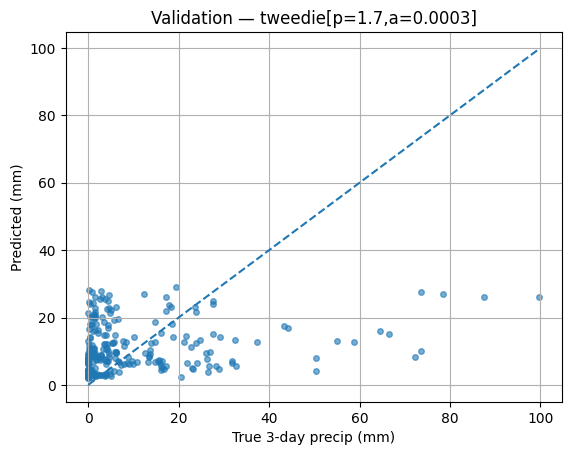

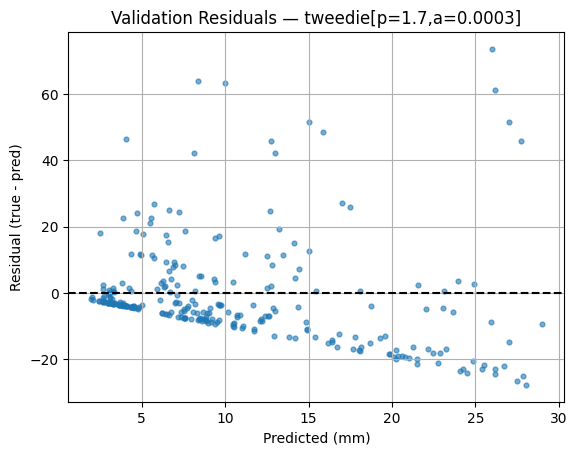

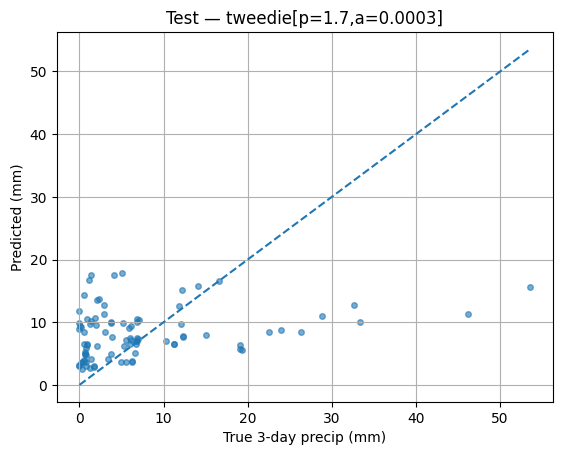

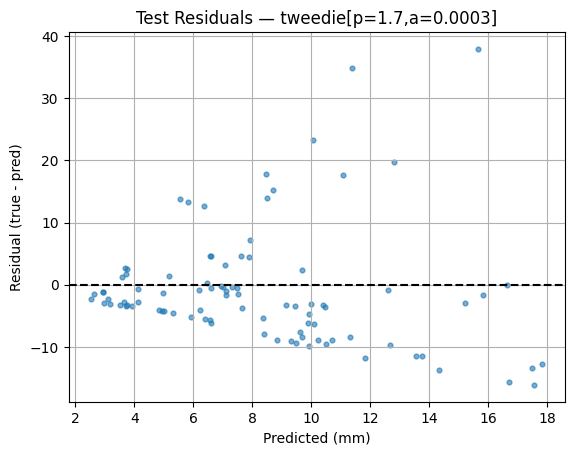

Zero-rate: y_val=0.179, y_test=0.055
Pred zero-rate: val=0.000, test=0.000


In [75]:

# Validation (post-refit; informative only)
yhat_val = np.clip(best_model.predict(Xval), 0.0, None)
val_card = reg_report(yval, yhat_val, name=f"{best_name}_val")

# Test (true holdout)
yhat_te = np.clip(best_model.predict(Xte), 0.0, None)
te_card  = reg_report(yte,  yhat_te,  name=f"{best_name}_test")

print("Validation (post-refit):", val_card)
print("Test:", te_card)

# Plots
scatter_true_vs_pred(yval, yhat_val, title=f"Validation — {best_name}")
residual_plot(yval, yhat_val, title=f"Validation Residuals — {best_name}")

scatter_true_vs_pred(yte, yhat_te, title=f"Test — {best_name}")
residual_plot(yte, yhat_te, title=f"Test Residuals — {best_name}")

# Some descriptive stats for context
def _zero_rate(y):
    y = np.asarray(y, float).ravel()
    return float((y <= 1e-9).mean())

print(f"Zero-rate: y_val={_zero_rate(yval):.3f}, y_test={_zero_rate(yte):.3f}")
print(f"Pred zero-rate: val={_zero_rate(yhat_val):.3f}, test={_zero_rate(yhat_te):.3f}")

In [94]:
# <Student to fill this section>
model_performance_explanations = """
Model performance (regression — 3-day precip, Tweedie[p=1.7, α=3e-4]). Model is useful for typical precipitation amounts but not yet reliable for tail-risk planning (storms). Next gains likely from tail-aware losses (quantile/Pinball), zero-inflated or hurdle variants, and adding pressure/humidity dynamics or de-seasonalized anomaly features.

(i) Overall fit: Val RMSE≈15.73 mm, MAE≈10.66 mm, R²≈0.026; Test RMSE≈9.54 mm, MAE≈6.70 mm, R²≈0.064. Small gain vs mean baseline on Val; clearer gain on the (drier) Test window.

(ii) Bias patterns: Scatter plots show systematic under-prediction on heavy events (points fall below y=x at high true totals). Residuals vs ŷ trend downward with larger predictions, indicating increasing error magnitude for wetter cases and mild over-prediction for mid-range days.

(iii) Range & constraints: Log-link Tweedie enforces non-negative outputs and compresses the upper tail, which improves stability but caps extremes, explaining the miss on very wet 3-day periods.
"""

In [95]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

In [98]:
# <Student to fill this section>
business_impacts_explanations = """
Business impacts — 3-day precipitation API (best model: Tweedie). The model is reasonably accurate for typical totals (Test RMSE≈9.5 mm, MAE≈6.9 mm) but systematically under-predicts heavy events. It improves planning for most days, yet tail risk (storms) still needs caution.
(A)Impact assessment:
(i) Impact when right: Better crew/equipment allocation, timely tarping/drainage, fewer last-minute changes, reduced overtime and penalties, safer sites, and higher on-time delivery.
(B) Impact when wrong (highest → lowest):
(i) Underestimation of heavy rain (highest impact): Leads to flood/water damage, missed deadlines, safety incidents, and refunds. Even a 10–20 mm miss over 3 days can be costly for outdoor works. Mitigation: add conservative buffers/alerts when predicted totals exceed moderate levels, show prediction intervals, and escalate if recent volatility is high.
(ii) Miscalibration / unquantified uncertainty (medium–high): Overconfidence in amounts can mis-set client thresholds, causing both over- and under-reaction. Mitigation: serve uncertainty bands, monthly recalibration, and tail-error monitoring.
(iii) Overestimation (medium): Unnecessary rescheduling/prep and alarm fatigue, but generally cheaper than missed heavy rain. Mitigation: cost-aware thresholds and suppress low-confidence “wet” calls.
Operational guidance: Exposing predicted mm + uncertainty, highlighting tail-risk flags (recent 14-day volatility, low radiation), with cost-tuned actions (e.g., contingency if upper interval is high). Prioritizing improvements that reduce tail under-prediction to deliver the biggest business benefit.
"""

In [99]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## K. Project Outcomes

In [100]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Partially Confirmed"

In [101]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [105]:
# <Student to fill this section>
experiment_results_explanations = """
Outcome & insights: 

(i) Tweedie (log-link) is the current best: RMSE≈9.5 mm, MAE≈6.9 mm, small +R² on test.

(ii) Works well for typical totals but under-predicts heavy events; residuals grow with prediction (heteroscedastic, right-tail bias).

(iii) Recent-regime features help; variance/energy terms (radiation, wind, wetness std) are more useful than raw means.

(iv) Zero-inflation is low on test but higher on val; hurdle approach needs better calibration and didn’t yet beat Tweedie.

(v) Prospects: Errors are concentrated in tails; these are exactly the costs our users care about. The signal is present; better loss functions, features, and uncertainty will likely reduce tail misses without needing new data sources immediately.

(vi) Next steps (ranked by expected uplift):
(a) Quantile/PI forecasts (NGBoost/LightGBM quantiles or Tweedie + bootstrapped PIs) – add upper/lower bands; high uplift for decision-making even if point RMSE changes little.
(b) Tail-aware training – gradient boosting (HGB/XGBoost) with Tweedie/Poisson/Huber loss, class-balanced sampling on wet windows; medium-high uplift on heavy-rain under-prediction.
(c) Seasonalization & de-trending – monthly intercepts or de-seasonalized anomalies (radiation, humidity, pressure), plus recent-volatility features; medium uplift, reduces drift.
(d) Zero-inflation refinements – improved hurdle/gamma models with calibrated P(y>0); medium uplift on light-rain days.
(e) Feature audits – drop collinear rain/precip duplicates, add pressure/VPD, wind shear; small-medium uplift, better stability.
(f) Time-aware CV & recalibration pipeline – rolling-origin CV, monthly calibration checks; risk reduction.

"""

In [106]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)

## L. Saving the Best Model

In [85]:
OUT_DIR = "/Users/naynajahanneha/Documents/DataScience/AMLA/AST2/amla_at2_experiments/models/precipitation_fall"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

cols = list(Xtr.columns)
setattr(best_model, "_training_columns", cols)

MODEL_PATH = os.path.join(OUT_DIR, "best_precipitation_reg_pipeline.joblib")
dump(best_model, MODEL_PATH)
print("Saved:", MODEL_PATH)

Saved: /Users/naynajahanneha/Documents/DataScience/AMLA/AST2/amla_at2_experiments/models/precipitation_fall/best_precipitation_reg_pipeline.joblib
